# 🔄 RNN for RUL Prediction Tutorial

## Learning Objectives

By the end of this tutorial, you will:
- Understand why RNNs are ideal for RUL prediction (time series data)
- Learn to create sequences from engine sensor data
- Build and train RNN models (SimpleRNN, LSTM, GRU) for RUL prediction
- Compare RNN performance with different architectures
- Visualize RNN architecture and data flow for RUL prediction
- Evaluate RUL predictions using regression metrics
- Understand how temporal patterns help predict engine degradation

---

## What is RUL Prediction with RNNs?

**RUL (Remaining Useful Life)** prediction using RNNs leverages the **temporal nature** of engine degradation.

### Why Use RNNs for RUL Prediction?

- **Time Series Nature**: Engine sensor readings form a time series
- **Temporal Dependencies**: Current RUL depends on past sensor readings
- **Sequential Patterns**: Degradation patterns unfold over time
- **Memory**: RNNs remember past states to predict future RUL

### Key Advantage Over Feedforward Networks:

| Aspect | Feedforward NN | RNN |
|--------|----------------|-----|
| **Input** | Single timestep | Sequence of timesteps |
| **Context** | No temporal context | Uses past sensor readings |
| **Pattern Learning** | Static patterns | Temporal degradation patterns |
| **Memory** | None | Maintains hidden state |

### Our Goal:

Predict **how many cycles** an engine has left before failure, using:
- **Sequences** of sensor readings (not just current values)
- **Temporal patterns** in engine degradation
- **Historical context** from previous cycles

This is a **time series regression problem** - perfect for RNNs!

---

## Step 1: Import Required Libraries

In [1]:
# Import libraries for data handling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle, Rectangle, Arrow, FancyArrowPatch
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import machine learning components
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# TensorFlow/Keras for RNNs
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set visualization style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')

sns.set_palette("husl")
%matplotlib inline

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

2026-02-13 20:44:01.935442: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ Libraries imported successfully!
TensorFlow version: 2.20.0


## Step 2: Load and Prepare the Data

In [2]:
# Define data path
data_path = Path('dataset/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData')

# Column names with actual field names
op_settings = ['Altitude', 'Mach', 'TRA']
sensors = [
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 
    'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32'
]
column_names = ['unit', 'time'] + op_settings + sensors

def load_data(dataset='FD001'):
    """Load training and test data from CSV files"""
    train_file = data_path / f'train_{dataset}.csv'
    test_file = data_path / f'test_{dataset}.csv'
    rul_file = data_path / f'RUL_{dataset}.csv'
    
    train_df = pd.read_csv(train_file)
    test_df = pd.read_csv(test_file)
    rul_df = pd.read_csv(rul_file)
    
    return train_df, test_df, rul_df

def calculate_rul_train(df):
    """Calculate RUL (Remaining Useful Life) for training data"""
    df = df.copy()
    df['RUL'] = df.groupby('unit')['time'].transform(lambda x: x.max() - x)
    return df

# Load data for FD001 dataset
train_df, test_df, rul_df = load_data('FD001')
train_df = calculate_rul_train(train_df)

print("✅ Data loaded successfully!")
print(f"\\n📊 Training data shape: {train_df.shape}")
print(f"📊 Test data shape: {test_df.shape}")
print(f"🚁 Number of engines in training: {train_df['unit'].nunique()}")
print(f"🚁 Number of engines in test: {test_df['unit'].nunique()}")
print(f"⏱️  RUL range in training: {train_df['RUL'].min()} to {train_df['RUL'].max()} cycles")

✅ Data loaded successfully!
\n📊 Training data shape: (20631, 27)
📊 Test data shape: (13096, 26)
🚁 Number of engines in training: 100
🚁 Number of engines in test: 100
⏱️  RUL range in training: 0 to 361 cycles


## Step 3: Visualize RNN Architecture for RUL Prediction

Let's understand how RNNs process engine sensor sequences to predict RUL!

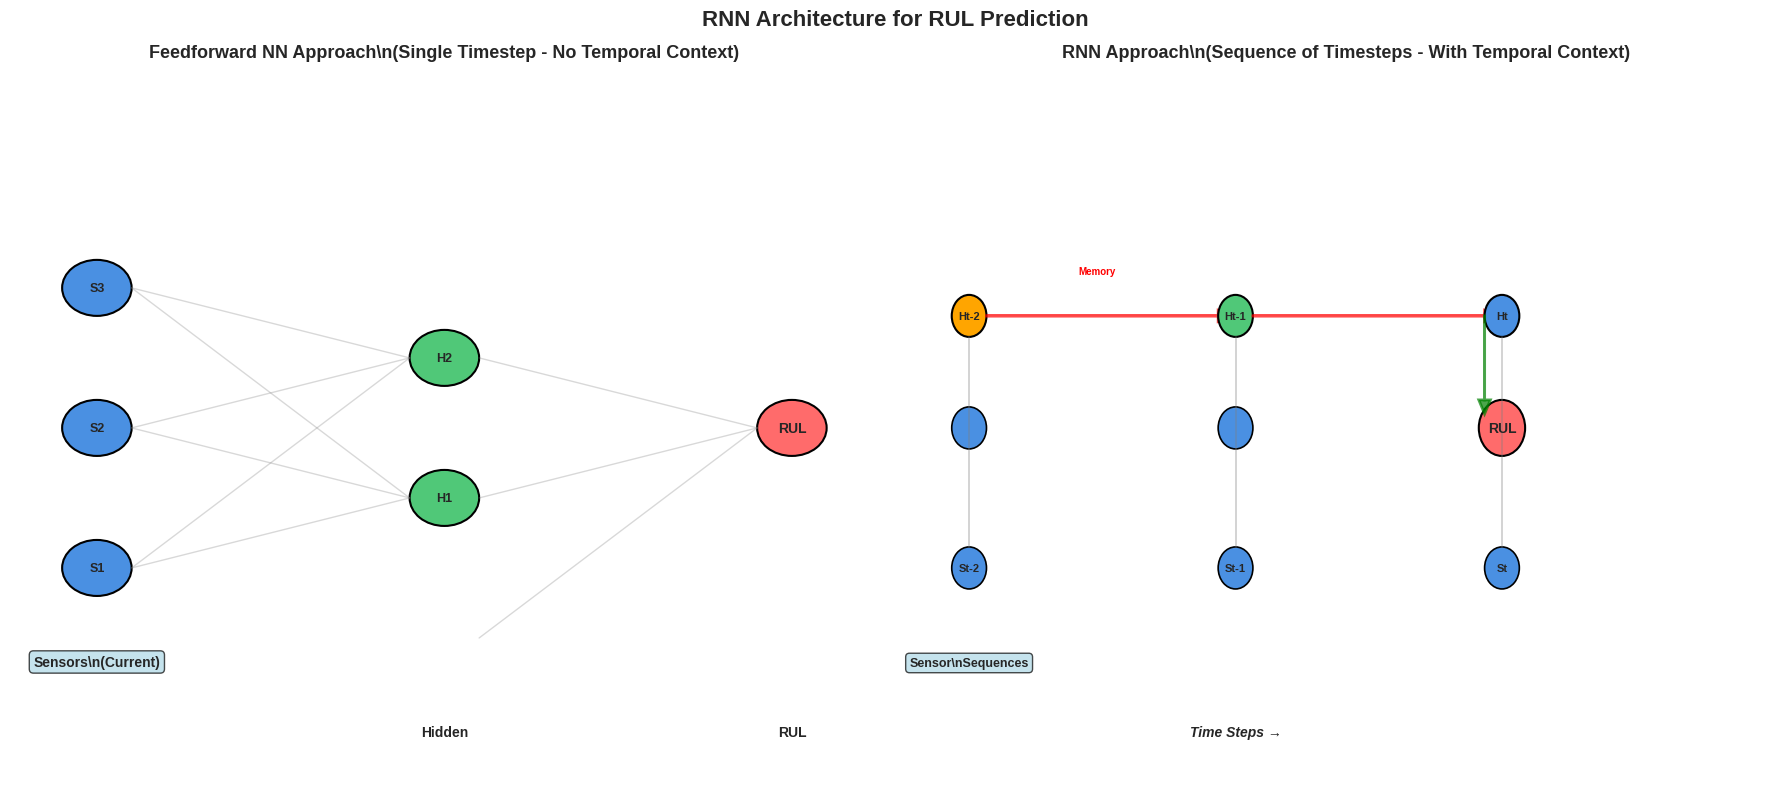

✅ RNN architecture visualization for RUL prediction created!
\n💡 Key Difference:
   - Feedforward: Uses only current sensor readings (no history)
   - RNN: Uses sequence of sensor readings (temporal context)
   - RNN can learn degradation patterns over time!


In [3]:
# Visualize RNN for RUL Prediction
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('RNN Architecture for RUL Prediction', fontsize=16, fontweight='bold')

# Left: Feedforward approach (single timestep)
ax1 = axes[0]
ax1.set_xlim(-0.5, 4.5)
ax1.set_ylim(-0.5, 4.5)
ax1.axis('off')
ax1.set_title('Feedforward NN Approach\\n(Single Timestep - No Temporal Context)', 
              fontsize=13, fontweight='bold', pad=15)

# Input (single timestep sensors)
for i in range(3):
    circle = Circle((0, i+1), 0.2, color='#4A90E2', ec='black', lw=1.5)
    ax1.add_patch(circle)
    ax1.text(0, i+1, f'S{i+1}', ha='center', va='center', fontsize=9, fontweight='bold')

ax1.text(0, 0.3, 'Sensors\\n(Current)', ha='center', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Hidden layers
for i in range(2):
    circle = Circle((2, i+1.5), 0.2, color='#50C878', ec='black', lw=1.5)
    ax1.add_patch(circle)
    ax1.text(2, i+1.5, f'H{i+1}', ha='center', va='center', fontsize=9, fontweight='bold')

# Output
circle = Circle((4, 2), 0.2, color='#FF6B6B', ec='black', lw=1.5)
ax1.add_patch(circle)
ax1.text(4, 2, 'RUL', ha='center', va='center', fontsize=10, fontweight='bold')

# Connections
for i in range(3):
    for j in range(2):
        ax1.plot([0.2, 1.8], [i+1, j+1.5], 'gray', alpha=0.3, linewidth=1)
    ax1.plot([2.2, 3.8], [i+0.5, 2], 'gray', alpha=0.3, linewidth=1)

ax1.text(2, -0.2, 'Hidden', ha='center', fontsize=10, fontweight='bold')
ax1.text(4, -0.2, 'RUL', ha='center', fontsize=10, fontweight='bold')

# Right: RNN approach (sequence of timesteps)
ax2 = axes[1]
ax2.set_xlim(-0.5, 7)
ax2.set_ylim(-0.5, 4.5)
ax2.axis('off')
ax2.set_title('RNN Approach\\n(Sequence of Timesteps - With Temporal Context)', 
              fontsize=13, fontweight='bold', pad=15)

# Time steps
time_labels = ['t-2', 't-1', 't']
colors = ['#FFA500', '#50C878', '#4A90E2']

for t_idx, (t_label, color) in enumerate(zip(time_labels, colors)):
    x_offset = t_idx * 2.3
    
    # Sensors at this timestep
    for i in range(2):
        circle = Circle((x_offset, i+1), 0.15, color='#4A90E2', ec='black', lw=1.2)
        ax2.add_patch(circle)
        if i == 0:
            ax2.text(x_offset, i+1, f'S{t_label}', ha='center', va='center', fontsize=8, fontweight='bold')
    
    # Hidden state
    circle = Circle((x_offset, 2.8), 0.15, color=color, ec='black', lw=1.5)
    ax2.add_patch(circle)
    ax2.text(x_offset, 2.8, f'H{t_label}', ha='center', va='center', fontsize=8, fontweight='bold')
    
    # Connections within timestep
    ax2.plot([x_offset, x_offset], [1.15, 2.65], 'gray', alpha=0.4, linewidth=1.2)
    
    # Recurrent connection
    if t_idx < len(time_labels) - 1:
        ax2.arrow(x_offset + 0.15, 2.8, 2.0, 0, head_width=0.08, head_length=0.12, 
                 fc='red', ec='red', linewidth=2, alpha=0.7)
        if t_idx == 0:
            ax2.text(x_offset + 1.1, 3.1, 'Memory', ha='center', fontsize=7, color='red', fontweight='bold')

# Output RUL (at last timestep)
circle = Circle((4.6, 2), 0.2, color='#FF6B6B', ec='black', lw=1.5)
ax2.add_patch(circle)
ax2.text(4.6, 2, 'RUL', ha='center', va='center', fontsize=10, fontweight='bold')

# Connection from last hidden to RUL
ax2.arrow(4.6 - 0.15, 2.8, 0, -0.6, head_width=0.1, head_length=0.1, 
         fc='green', ec='green', linewidth=2, alpha=0.7)

ax2.text(2.3, -0.2, 'Time Steps →', ha='center', fontsize=10, fontweight='bold', style='italic')
ax2.text(0, 0.3, 'Sensor\\nSequences', ha='center', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.show()

print("✅ RNN architecture visualization for RUL prediction created!")
print("\\n💡 Key Difference:")
print("   - Feedforward: Uses only current sensor readings (no history)")
print("   - RNN: Uses sequence of sensor readings (temporal context)")
print("   - RNN can learn degradation patterns over time!")

✅ Sequences created from engine data!
\n📊 Sequence Statistics:
   - Number of sequences: 17,731
   - Sequence length: 30 cycles
   - Features per timestep: 24
   - Data shape: (sequences, timesteps, features) = (17731, 30, 24)
   - Target shape: (17731,)
   - RUL range: [0, 332] cycles


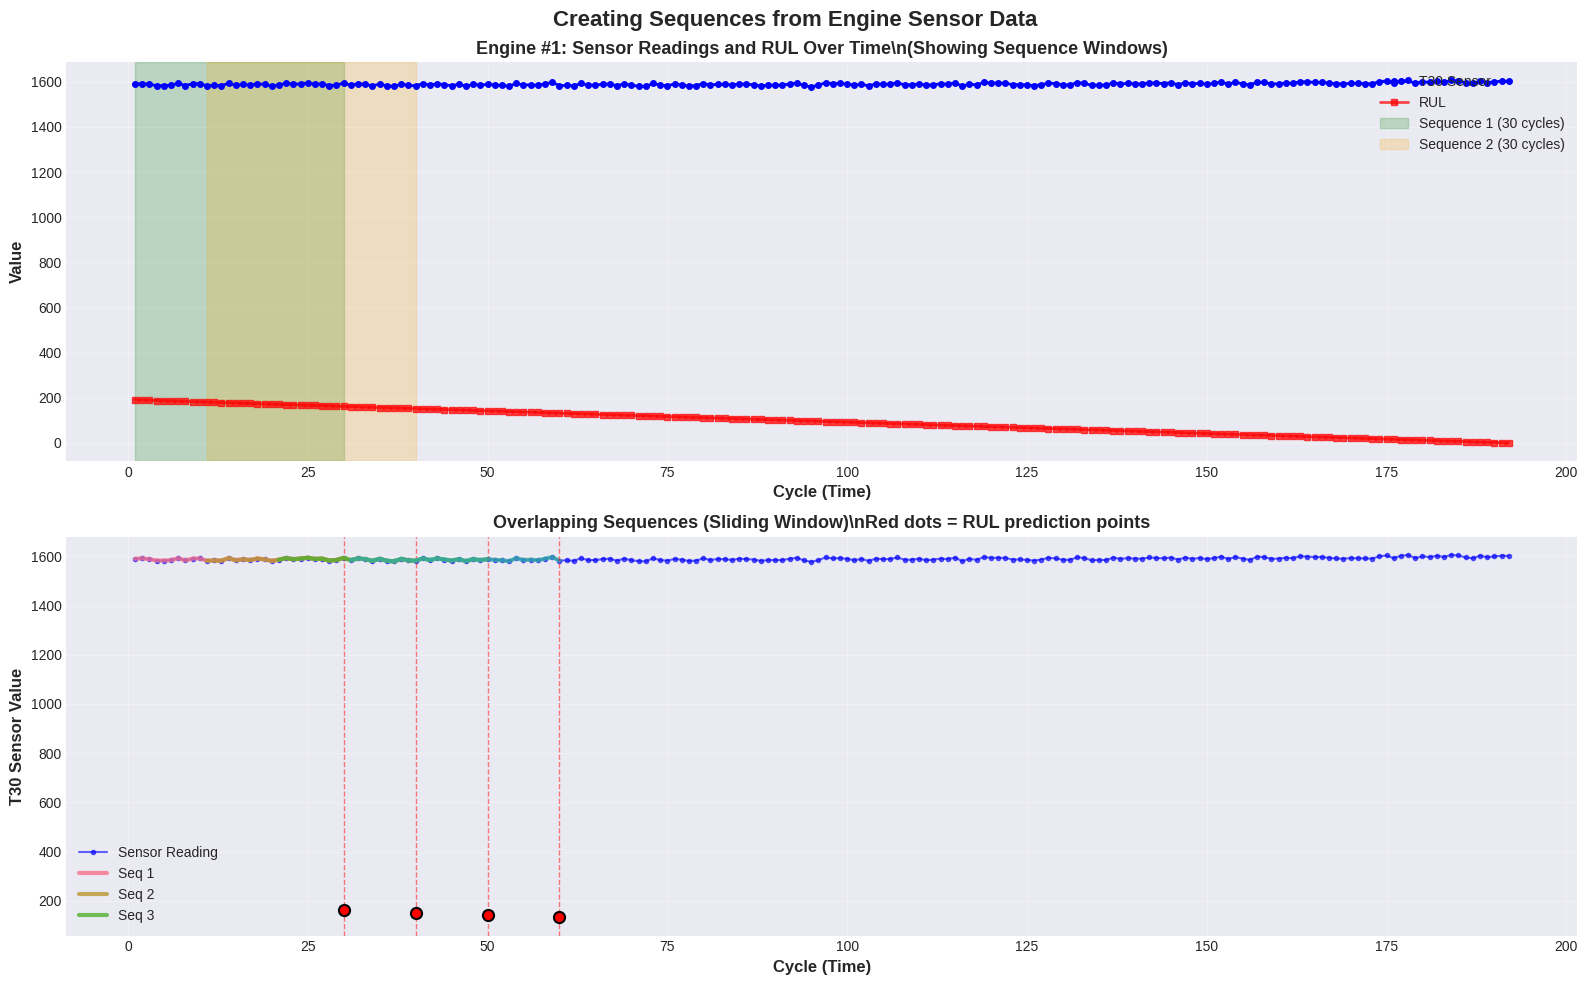

\n💡 Understanding Sequences for RUL:
   - Each sequence contains 30 consecutive cycles
   - Sequences overlap (sliding window approach)
   - RNN uses sensor readings from all {sequence_length} cycles to predict RUL
   - This captures degradation patterns over time!


In [4]:
def create_sequences(data, sequence_length=30):
    """
    Create sequences for RNN training from engine data
    
    Parameters:
    -----------
    data : DataFrame
        Training data with sensor readings and RUL
    sequence_length : int
        Number of timesteps (cycles) to use for prediction
    
    Returns:
    --------
    X_seq : array, shape (n_sequences, sequence_length, n_features)
        Input sequences (sensor readings over time)
    y_seq : array, shape (n_sequences,)
        Target RUL values
    """
    sequences = []
    targets = []
    
    # Select features (sensors + operational settings, exclude unit, time, RUL)
    feature_cols = op_settings + sensors
    
    # For each engine, create sequences
    for unit_id in data['unit'].unique():
        unit_data = data[data['unit'] == unit_id].sort_values('time')
        unit_features = unit_data[feature_cols].values
        unit_rul = unit_data['RUL'].values
        
        # Create sequences using sliding window
        for i in range(len(unit_data) - sequence_length + 1):
            sequences.append(unit_features[i:i+sequence_length])
            targets.append(unit_rul[i+sequence_length-1])  # RUL at end of sequence
    
    return np.array(sequences), np.array(targets)

# Create sequences
sequence_length = 30  # Use 30 cycles to predict RUL
X_train_seq, y_train_seq = create_sequences(train_df, sequence_length)

print("✅ Sequences created from engine data!")
print(f"\\n📊 Sequence Statistics:")
print(f"   - Number of sequences: {X_train_seq.shape[0]:,}")
print(f"   - Sequence length: {X_train_seq.shape[1]} cycles")
print(f"   - Features per timestep: {X_train_seq.shape[2]}")
print(f"   - Data shape: (sequences, timesteps, features) = {X_train_seq.shape}")
print(f"   - Target shape: {y_train_seq.shape}")
print(f"   - RUL range: [{y_train_seq.min()}, {y_train_seq.max()}] cycles")

# Visualize how sequences are created from engine data
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Creating Sequences from Engine Sensor Data', fontsize=16, fontweight='bold')

# Example: One engine's sensor data over time
example_unit = train_df[train_df['unit'] == 1].sort_values('time')
example_sensor = 'T30'  # Temperature sensor

# Plot 1: Engine sensor readings over time
axes[0].plot(example_unit['time'], example_unit[example_sensor], 
            'o-', linewidth=2, markersize=4, label=f'{example_sensor} Sensor', color='blue')
axes[0].plot(example_unit['time'], example_unit['RUL'], 
            's-', linewidth=2, markersize=4, label='RUL', color='red', alpha=0.7)
axes[0].axvspan(example_unit['time'].iloc[0], example_unit['time'].iloc[sequence_length-1], 
               alpha=0.2, color='green', label=f'Sequence 1 ({sequence_length} cycles)')
axes[0].axvspan(example_unit['time'].iloc[10], example_unit['time'].iloc[10+sequence_length-1], 
               alpha=0.2, color='orange', label=f'Sequence 2 ({sequence_length} cycles)')
axes[0].set_xlabel('Cycle (Time)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Value', fontsize=12, fontweight='bold')
axes[0].set_title(f'Engine #1: Sensor Readings and RUL Over Time\\n(Showing Sequence Windows)', 
                 fontsize=13, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Plot 2: Multiple sequences visualization
axes[1].plot(example_unit['time'], example_unit[example_sensor], 
            'o-', linewidth=1.5, markersize=3, alpha=0.6, color='blue', label='Sensor Reading')
for seq_start in [0, 10, 20, 30]:
    if seq_start + sequence_length <= len(example_unit):
        seq_end = seq_start + sequence_length - 1
        axes[1].plot(example_unit['time'].iloc[seq_start:seq_end+1], 
                    example_unit[example_sensor].iloc[seq_start:seq_end+1],
                    linewidth=3, alpha=0.8, label=f'Seq {seq_start//10+1}' if seq_start < 30 else '')
        axes[1].axvline(x=example_unit['time'].iloc[seq_end], color='red', 
                       linestyle='--', linewidth=1, alpha=0.5)
        # Mark prediction point
        axes[1].plot(example_unit['time'].iloc[seq_end], example_unit['RUL'].iloc[seq_end],
                    'ro', markersize=8, markeredgecolor='black', markeredgewidth=1.5)

axes[1].set_xlabel('Cycle (Time)', fontsize=12, fontweight='bold')
axes[1].set_ylabel(f'{example_sensor} Sensor Value', fontsize=12, fontweight='bold')
axes[1].set_title(f'Overlapping Sequences (Sliding Window)\\nRed dots = RUL prediction points', 
                 fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\\n💡 Understanding Sequences for RUL:")
print(f"   - Each sequence contains {sequence_length} consecutive cycles")
print("   - Sequences overlap (sliding window approach)")
print("   - RNN uses sensor readings from all {sequence_length} cycles to predict RUL")
print("   - This captures degradation patterns over time!")

In [5]:
# Scale the features (crucial for RNNs!)
# Reshape sequences for scaling: (samples * timesteps, features)
n_samples, n_timesteps, n_features = X_train_seq.shape
X_reshaped = X_train_seq.reshape(-1, n_features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped)

# Reshape back to sequences
X_train_seq_scaled = X_scaled.reshape(n_samples, n_timesteps, n_features)

# Split into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_seq_scaled, y_train_seq, test_size=0.2, random_state=42
)

print("✅ Features scaled and data split!")
print(f"\\n📊 Final Data Shapes:")
print(f"   - Training sequences: {X_train_split.shape[0]:,}")
print(f"   - Validation sequences: {X_val_split.shape[0]:,}")
print(f"   - Sequence length: {n_timesteps} cycles")
print(f"   - Features per timestep: {n_features}")
print(f"   - Data shape: (sequences, timesteps, features) = {X_train_split.shape}")

✅ Features scaled and data split!
\n📊 Final Data Shapes:
   - Training sequences: 14,184
   - Validation sequences: 3,547
   - Sequence length: 30 cycles
   - Features per timestep: 24
   - Data shape: (sequences, timesteps, features) = (14184, 30, 24)


## Step 6: Build and Train Simple RNN

Let's start with a basic SimpleRNN for RUL prediction.

In [6]:
# Build Simple RNN model for RUL prediction
model_simple_rnn = Sequential([
    SimpleRNN(128, activation='tanh', return_sequences=False, 
              input_shape=(n_timesteps, n_features), name='rnn_layer_1'),
    Dense(64, activation='relu', name='dense_layer_1'),
    Dense(1, name='output_layer')  # Output: RUL (single value)
])

# Compile the model
model_simple_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Display model architecture
print("📊 Simple RNN Architecture for RUL Prediction:")
print("=" * 60)
model_simple_rnn.summary()

print("\\n💡 Architecture Explanation:")
print(f"   - Input: Sequences of shape ({n_timesteps}, {n_features})")
print("   - SimpleRNN(128): Processes sequence, outputs hidden state")
print("   - Dense layers: Transform RNN output to RUL prediction")
print("   - Output: Single RUL value (in cycles)")

📊 Simple RNN Architecture for RUL Prediction:


2026-02-13 20:44:04.438259: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_layer_1 (SimpleRNN)         │ (None, 128)            │        19,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer_1 (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,905 (109.00 KB)

 Trainable params: 27,905 (109.00 KB)

 Non-trainable params: 0 (0.00 B)

\n💡 Architecture Explanation:
   - Input: Sequences of shape (30, 24)
   - SimpleRNN(128): Processes sequence, outputs hidden state
   - Dense layers: Transform RNN output to RUL prediction
   - Output: Single RUL value (in cycles)


In [7]:
# Train the Simple RNN model
print("🚀 Training Simple RNN for RUL Prediction...")
print("=" * 60)

history_simple_rnn = model_simple_rnn.fit(
    X_train_split, y_train_split,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_split, y_val_split),
    verbose=1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

print("\\n✅ Training completed!")

🚀 Training Simple RNN for RUL Prediction...
Epoch 1/50


2026-02-13 20:44:04.617087: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 40849920 exceeds 10% of free system memory.


444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3985.7671 - mae: 45.9544 - val_loss: 1589.0040 - val_mae: 28.3090
Epoch 2/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1366.7661 - mae: 25.8392 - val_loss: 1387.1418 - val_mae: 25.4405
Epoch 3/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1282.0394 - mae: 24.7451 - val_loss: 1341.2246 - val_mae: 24.7652
Epoch 4/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1256.5492 - mae: 24.4370 - val_loss: 1287.3699 - val_mae: 24.7876
Epoch 5/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1251.7721 - mae: 24.3812 - val_loss: 1292.6285 - val_mae: 24.4142
Epoch 6/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1239.3975 - mae: 24.2567 - val_loss: 1283.8875 - val_mae: 23.9835
Epoch 7/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1263.9060 - mae: 24.5399 - val_loss: 1312.1667 - val_mae: 24.5131
Epoch 8/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1255.0825 - mae: 24.4372 - val_loss: 1288.2219 - val_mae: 24.3075
Epo

In [8]:
# Evaluate Simple RNN on validation set
y_pred_simple_rnn = model_simple_rnn.predict(X_val_split, verbose=0)

mse_simple_rnn = mean_squared_error(y_val_split, y_pred_simple_rnn)
mae_simple_rnn = mean_absolute_error(y_val_split, y_pred_simple_rnn)
rmse_simple_rnn = np.sqrt(mse_simple_rnn)
r2_simple_rnn = r2_score(y_val_split, y_pred_simple_rnn)

print("📊 Simple RNN Performance (Validation Set):")
print("=" * 60)
print(f"MSE:  {mse_simple_rnn:.2f}")
print(f"MAE:  {mae_simple_rnn:.2f} cycles")
print(f"RMSE: {rmse_simple_rnn:.2f} cycles")
print(f"R²:   {r2_simple_rnn:.4f}")

print(f"\\n💡 Interpretation:")
print(f"   - On average, predictions are off by {mae_simple_rnn:.2f} cycles")
print(f"   - Model explains {r2_simple_rnn*100:.1f}% of variance in RUL")

📊 Simple RNN Performance (Validation Set):
MSE:  1265.43
MAE:  24.11 cycles
RMSE: 35.57 cycles
R²:   0.6692
\n💡 Interpretation:
   - On average, predictions are off by 24.11 cycles
   - Model explains 66.9% of variance in RUL


## Step 7: Build and Train LSTM

LSTM can remember longer-term degradation patterns, which is important for RUL prediction.

In [9]:
# Build LSTM model for RUL prediction
model_lstm = Sequential([
    LSTM(128, activation='tanh', return_sequences=False, 
         input_shape=(n_timesteps, n_features), name='lstm_layer_1'),
    Dense(64, activation='relu', name='dense_layer_1'),
    Dense(1, name='output_layer')  # Output: RUL
])

# Compile the model
model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Display model architecture
print("📊 LSTM Architecture for RUL Prediction:")
print("=" * 60)
model_lstm.summary()

print("\\n💡 Why LSTM for RUL?")
print("   - Engine degradation happens over many cycles")
print("   - LSTM can remember long-term patterns")
print("   - Better at capturing gradual degradation trends")
print("   - Gates control what to remember/forget")

📊 LSTM Architecture for RUL Prediction:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer_1 (LSTM)             │ (None, 128)            │        78,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer_1 (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,657 (338.50 KB)

 Trainable params: 86,657 (338.50 KB)

 Non-trainable params: 0 (0.00 B)

\n💡 Why LSTM for RUL?
   - Engine degradation happens over many cycles
   - LSTM can remember long-term patterns
   - Better at capturing gradual degradation trends
   - Gates control what to remember/forget


In [10]:
# Train the LSTM model
print("🚀 Training LSTM for RUL Prediction...")
print("=" * 60)

history_lstm = model_lstm.fit(
    X_train_split, y_train_split,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_split, y_val_split),
    verbose=1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

print("\\n✅ Training completed!")

🚀 Training LSTM for RUL Prediction...
Epoch 1/50


2026-02-13 20:44:32.420963: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 40849920 exceeds 10% of free system memory.


444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 2776.6963 - mae: 36.0318 - val_loss: 1243.4652 - val_mae: 25.0176
Epoch 2/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1174.3772 - mae: 23.8046 - val_loss: 1020.8019 - val_mae: 22.5677
Epoch 3/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 997.2405 - mae: 21.6510 - val_loss: 886.8098 - val_mae: 20.9776
Epoch 4/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 915.1142 - mae: 20.5983 - val_loss: 847.8291 - val_mae: 20.3873
Epoch 5/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 889.0079 - mae: 20.2356 - val_loss: 849.5718 - val_mae: 20.1508
Epoch 6/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 823.5643 - mae: 19.4693 - val_loss: 769.7756 - val_mae: 19.2562
Epoch 7/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 771.8382 - mae: 18.7981 - val_loss: 725.8120 - val_mae: 18.4282
Epoch 8/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 723.6600 - mae: 18.2235 - val_loss: 683.8398 - val_mae: 17.9887
Epoch 9/50
444/

In [11]:
# Evaluate LSTM on validation set
y_pred_lstm = model_lstm.predict(X_val_split, verbose=0)

mse_lstm = mean_squared_error(y_val_split, y_pred_lstm)
mae_lstm = mean_absolute_error(y_val_split, y_pred_lstm)
rmse_lstm = np.sqrt(mse_lstm)
r2_lstm = r2_score(y_val_split, y_pred_lstm)

print("📊 LSTM Performance (Validation Set):")
print("=" * 60)
print(f"MSE:  {mse_lstm:.2f}")
print(f"MAE:  {mae_lstm:.2f} cycles")
print(f"RMSE: {rmse_lstm:.2f} cycles")
print(f"R²:   {r2_lstm:.4f}")

print(f"\\n💡 Interpretation:")
print(f"   - On average, predictions are off by {mae_lstm:.2f} cycles")
print(f"   - Model explains {r2_lstm*100:.1f}% of variance in RUL")

📊 LSTM Performance (Validation Set):
MSE:  125.81
MAE:  8.03 cycles
RMSE: 11.22 cycles
R²:   0.9671
\n💡 Interpretation:
   - On average, predictions are off by 8.03 cycles
   - Model explains 96.7% of variance in RUL


## Step 8: Build and Train GRU

GRU is simpler than LSTM but often performs similarly for RUL prediction.

In [12]:
# Build GRU model for RUL prediction
model_gru = Sequential([
    GRU(128, activation='tanh', return_sequences=False, 
        input_shape=(n_timesteps, n_features), name='gru_layer_1'),
    Dense(64, activation='relu', name='dense_layer_1'),
    Dense(1, name='output_layer')  # Output: RUL
])

# Compile the model
model_gru.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Display model architecture
print("📊 GRU Architecture for RUL Prediction:")
print("=" * 60)
model_gru.summary()

print("\\n💡 GRU for RUL:")
print("   - Simpler than LSTM (fewer parameters)")
print("   - Often similar performance to LSTM")
print("   - Faster to train")
print("   - Good balance for RUL prediction")

📊 GRU Architecture for RUL Prediction:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_layer_1 (GRU)               │ (None, 128)            │        59,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer_1 (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,457 (263.50 KB)

 Trainable params: 67,457 (263.50 KB)

 Non-trainable params: 0 (0.00 B)

\n💡 GRU for RUL:
   - Simpler than LSTM (fewer parameters)
   - Often similar performance to LSTM
   - Faster to train
   - Good balance for RUL prediction


In [13]:
# Train the GRU model
print("🚀 Training GRU for RUL Prediction...")
print("=" * 60)

history_gru = model_gru.fit(
    X_train_split, y_train_split,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_split, y_val_split),
    verbose=1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

print("\\n✅ Training completed!")

🚀 Training GRU for RUL Prediction...
Epoch 1/50


2026-02-13 20:47:18.467663: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 40849920 exceeds 10% of free system memory.


444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 3023.7654 - mae: 37.4344 - val_loss: 1349.0353 - val_mae: 25.2958
Epoch 2/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1293.7573 - mae: 25.0289 - val_loss: 1258.3002 - val_mae: 24.1257
Epoch 3/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1141.0660 - mae: 23.0015 - val_loss: 1041.4189 - val_mae: 21.9209
Epoch 4/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1010.6577 - mae: 21.2131 - val_loss: 952.5328 - val_mae: 20.9946
Epoch 5/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 915.5413 - mae: 20.0358 - val_loss: 875.9367 - val_mae: 19.9876
Epoch 6/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 891.0438 - mae: 20.0619 - val_loss: 870.6495 - val_mae: 20.2107
Epoch 7/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 820.9315 - mae: 19.1672 - val_loss: 814.6876 - val_mae: 19.3688
Epoch 8/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 785.1837 - mae: 18.7916 - val_loss: 768.0245 - val_mae: 18.8949
Epoch 9/50
4

In [14]:
# Evaluate GRU on validation set
y_pred_gru = model_gru.predict(X_val_split, verbose=0)

mse_gru = mean_squared_error(y_val_split, y_pred_gru)
mae_gru = mean_absolute_error(y_val_split, y_pred_gru)
rmse_gru = np.sqrt(mse_gru)
r2_gru = r2_score(y_val_split, y_pred_gru)

print("📊 GRU Performance (Validation Set):")
print("=" * 60)
print(f"MSE:  {mse_gru:.2f}")
print(f"MAE:  {mae_gru:.2f} cycles")
print(f"RMSE: {rmse_gru:.2f} cycles")
print(f"R²:   {r2_gru:.4f}")

print(f"\\n💡 Interpretation:")
print(f"   - On average, predictions are off by {mae_gru:.2f} cycles")
print(f"   - Model explains {r2_gru*100:.1f}% of variance in RUL")

📊 GRU Performance (Validation Set):
MSE:  28.68
MAE:  4.03 cycles
RMSE: 5.36 cycles
R²:   0.9925
\n💡 Interpretation:
   - On average, predictions are off by 4.03 cycles
   - Model explains 99.3% of variance in RUL


## Step 9: Compare All RNN Models

In [15]:
# Create comparison table
comparison_data = {
    'Model': ['SimpleRNN', 'LSTM', 'GRU'],
    'MSE': [mse_simple_rnn, mse_lstm, mse_gru],
    'MAE (cycles)': [mae_simple_rnn, mae_lstm, mae_gru],
    'RMSE (cycles)': [rmse_simple_rnn, rmse_lstm, rmse_gru],
    'R²': [r2_simple_rnn, r2_lstm, r2_gru]
}

comparison_df = pd.DataFrame(comparison_data)

print("📊 RNN Model Comparison for RUL Prediction (Validation Set):")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Find best model
best_model_idx = comparison_df['R²'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'Model']
print(f"\\n🏆 Best Model: {best_model}")
print(f"   - R²: {comparison_df.loc[best_model_idx, 'R²']:.4f}")
print(f"   - RMSE: {comparison_df.loc[best_model_idx, 'RMSE (cycles)']:.2f} cycles")
print(f"   - MAE: {comparison_df.loc[best_model_idx, 'MAE (cycles)']:.2f} cycles")

📊 RNN Model Comparison for RUL Prediction (Validation Set):
    Model         MSE  MAE (cycles)  RMSE (cycles)       R²
SimpleRNN 1265.431519     24.113926      35.572904 0.669221
     LSTM  125.808380      8.031096      11.216433 0.967114
      GRU   28.682423      4.033937       5.355597 0.992503
\n🏆 Best Model: GRU
   - R²: 0.9925
   - RMSE: 5.36 cycles
   - MAE: 4.03 cycles


## Step 10: Visualize Training Progress

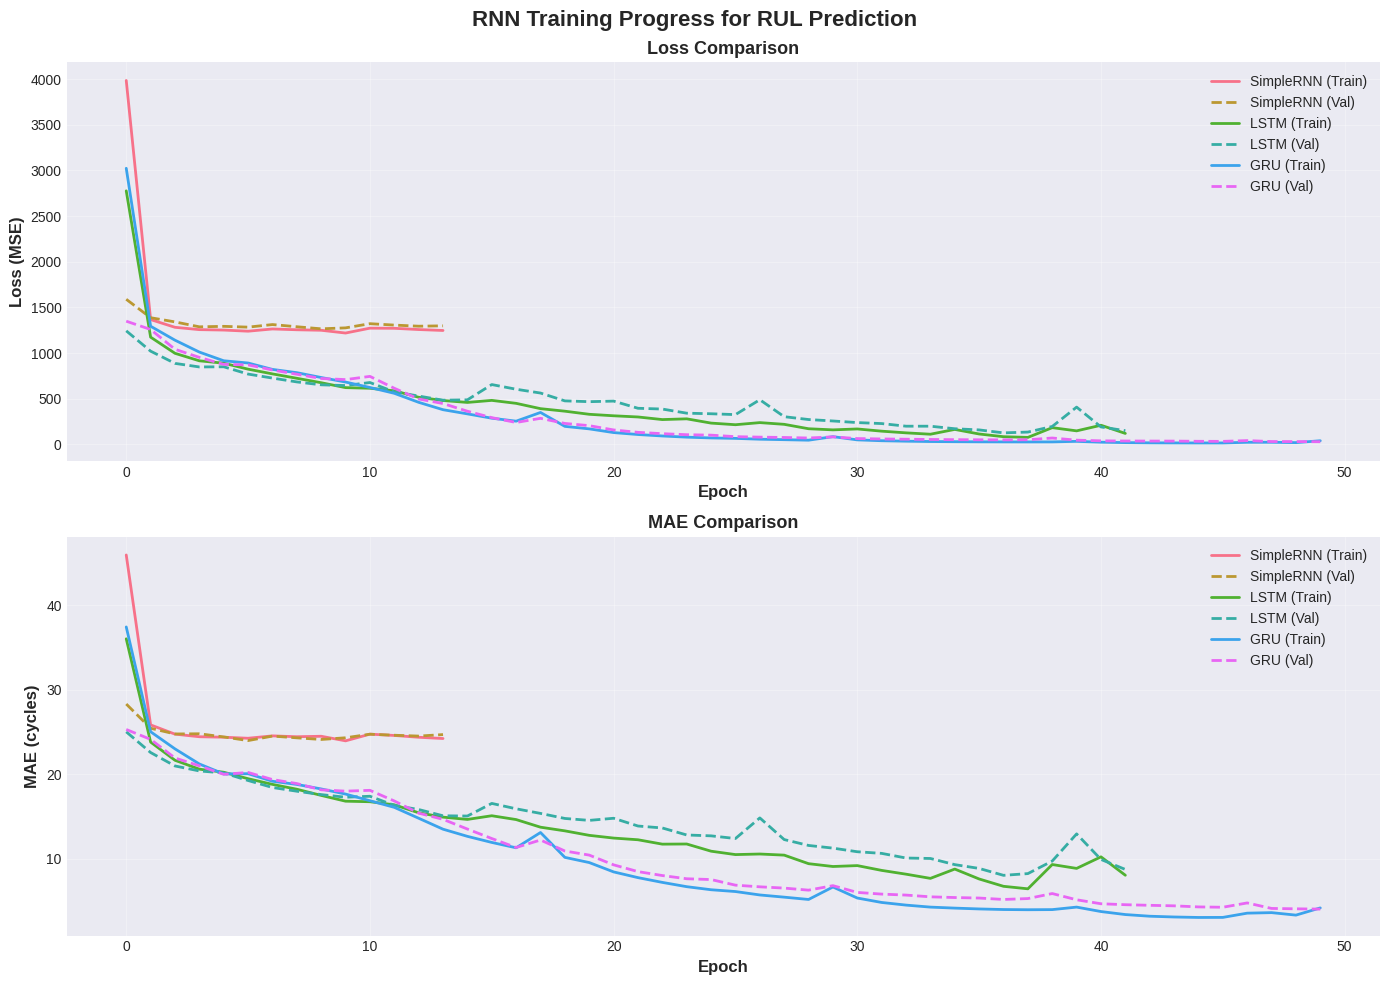

✅ Training progress visualization created!


In [16]:
# Plot training history for all RNN models
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('RNN Training Progress for RUL Prediction', fontsize=16, fontweight='bold')

# Loss comparison
axes[0].plot(history_simple_rnn.history['loss'], label='SimpleRNN (Train)', linestyle='-', linewidth=2)
axes[0].plot(history_simple_rnn.history['val_loss'], label='SimpleRNN (Val)', linestyle='--', linewidth=2)
axes[0].plot(history_lstm.history['loss'], label='LSTM (Train)', linestyle='-', linewidth=2)
axes[0].plot(history_lstm.history['val_loss'], label='LSTM (Val)', linestyle='--', linewidth=2)
axes[0].plot(history_gru.history['loss'], label='GRU (Train)', linestyle='-', linewidth=2)
axes[0].plot(history_gru.history['val_loss'], label='GRU (Val)', linestyle='--', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
axes[0].set_title('Loss Comparison', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE comparison
axes[1].plot(history_simple_rnn.history['mae'], label='SimpleRNN (Train)', linestyle='-', linewidth=2)
axes[1].plot(history_simple_rnn.history['val_mae'], label='SimpleRNN (Val)', linestyle='--', linewidth=2)
axes[1].plot(history_lstm.history['mae'], label='LSTM (Train)', linestyle='-', linewidth=2)
axes[1].plot(history_lstm.history['val_mae'], label='LSTM (Val)', linestyle='--', linewidth=2)
axes[1].plot(history_gru.history['mae'], label='GRU (Train)', linestyle='-', linewidth=2)
axes[1].plot(history_gru.history['val_mae'], label='GRU (Val)', linestyle='--', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE (cycles)', fontsize=12, fontweight='bold')
axes[1].set_title('MAE Comparison', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Training progress visualization created!")

## Step 11: Visualize RUL Predictions

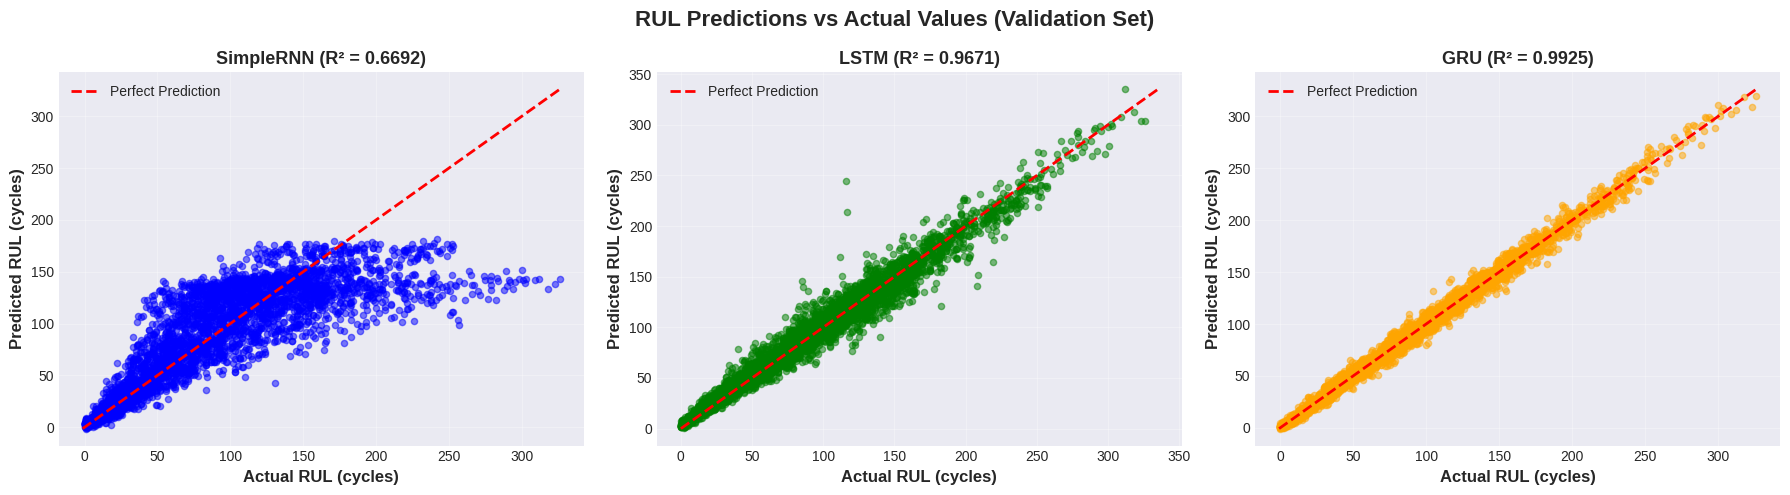

✅ Predictions visualization created!


In [17]:
# Plot predictions vs actual values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RUL Predictions vs Actual Values (Validation Set)', fontsize=16, fontweight='bold')

# SimpleRNN
axes[0].scatter(y_val_split, y_pred_simple_rnn, alpha=0.5, s=20, color='blue')
min_val = min(y_val_split.min(), y_pred_simple_rnn.min())
max_val = max(y_val_split.max(), y_pred_simple_rnn.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual RUL (cycles)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted RUL (cycles)', fontsize=12, fontweight='bold')
axes[0].set_title(f'SimpleRNN (R² = {r2_simple_rnn:.4f})', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LSTM
axes[1].scatter(y_val_split, y_pred_lstm, alpha=0.5, s=20, color='green')
min_val = min(y_val_split.min(), y_pred_lstm.min())
max_val = max(y_val_split.max(), y_pred_lstm.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual RUL (cycles)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted RUL (cycles)', fontsize=12, fontweight='bold')
axes[1].set_title(f'LSTM (R² = {r2_lstm:.4f})', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# GRU
axes[2].scatter(y_val_split, y_pred_gru, alpha=0.5, s=20, color='orange')
min_val = min(y_val_split.min(), y_pred_gru.min())
max_val = max(y_val_split.max(), y_pred_gru.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual RUL (cycles)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Predicted RUL (cycles)', fontsize=12, fontweight='bold')
axes[2].set_title(f'GRU (R² = {r2_gru:.4f})', fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Predictions visualization created!")

## Step 12: Evaluate on Test Set

Now let's evaluate the best model on the test set to see how it performs on unseen engines.

In [18]:
# Create test sequences
def create_test_sequences(data, sequence_length=30):
    """Create test sequences (last sequence_length timesteps for each engine)"""
    sequences = []
    feature_cols = op_settings + sensors
    
    for unit_id in sorted(data['unit'].unique()):
        unit_data = data[data['unit'] == unit_id].sort_values('time')
        unit_features = unit_data[feature_cols].values
        
        # Get last sequence_length timesteps
        if len(unit_data) >= sequence_length:
            sequences.append(unit_features[-sequence_length:])
        else:
            # Pad with first value if sequence is too short
            padding = np.tile(unit_features[0:1], (sequence_length - len(unit_data), 1))
            sequences.append(np.vstack([padding, unit_features]))
    
    return np.array(sequences)

# Create test sequences
X_test_seq = create_test_sequences(test_df, sequence_length)

# Scale test sequences
X_test_reshaped = X_test_seq.reshape(-1, n_features)
X_test_scaled = scaler.transform(X_test_reshaped)
X_test_seq_scaled = X_test_scaled.reshape(X_test_seq.shape[0], n_timesteps, n_features)

# Get actual RUL from the RUL file
y_test_actual = rul_df['RUL'].values

print("✅ Test data prepared!")
print(f"   - Test sequences: {X_test_seq_scaled.shape[0]}")
print(f"   - Actual RUL range: [{y_test_actual.min()}, {y_test_actual.max()}] cycles")

✅ Test data prepared!
   - Test sequences: 100
   - Actual RUL range: [7, 145] cycles


In [19]:
# Use the best model (LSTM) for test predictions
# You can change this to use SimpleRNN or GRU if they performed better
best_model = model_lstm
y_test_pred = best_model.predict(X_test_seq_scaled, verbose=0)

# Calculate metrics on test set
mse_test = mean_squared_error(y_test_actual, y_test_pred)
mae_test = mean_absolute_error(y_test_actual, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test_actual, y_test_pred)

print("📊 Best Model (LSTM) Performance on Test Set:")
print("=" * 60)
print(f"MSE:  {mse_test:.2f}")
print(f"MAE:  {mae_test:.2f} cycles")
print(f"RMSE: {rmse_test:.2f} cycles")
print(f"R²:   {r2_test:.4f}")

print(f"\\n💡 Interpretation:")
print(f"   - On average, predictions are off by {mae_test:.2f} cycles")
print(f"   - The model explains {r2_test*100:.1f}% of the variance in RUL")
print(f"   - This is performance on completely unseen engines!")

📊 Best Model (LSTM) Performance on Test Set:
MSE:  1313.50
MAE:  21.75 cycles
RMSE: 36.24 cycles
R²:   0.2394
\n💡 Interpretation:
   - On average, predictions are off by 21.75 cycles
   - The model explains 23.9% of the variance in RUL
   - This is performance on completely unseen engines!


## Step 13: Visualize Test Set Predictions

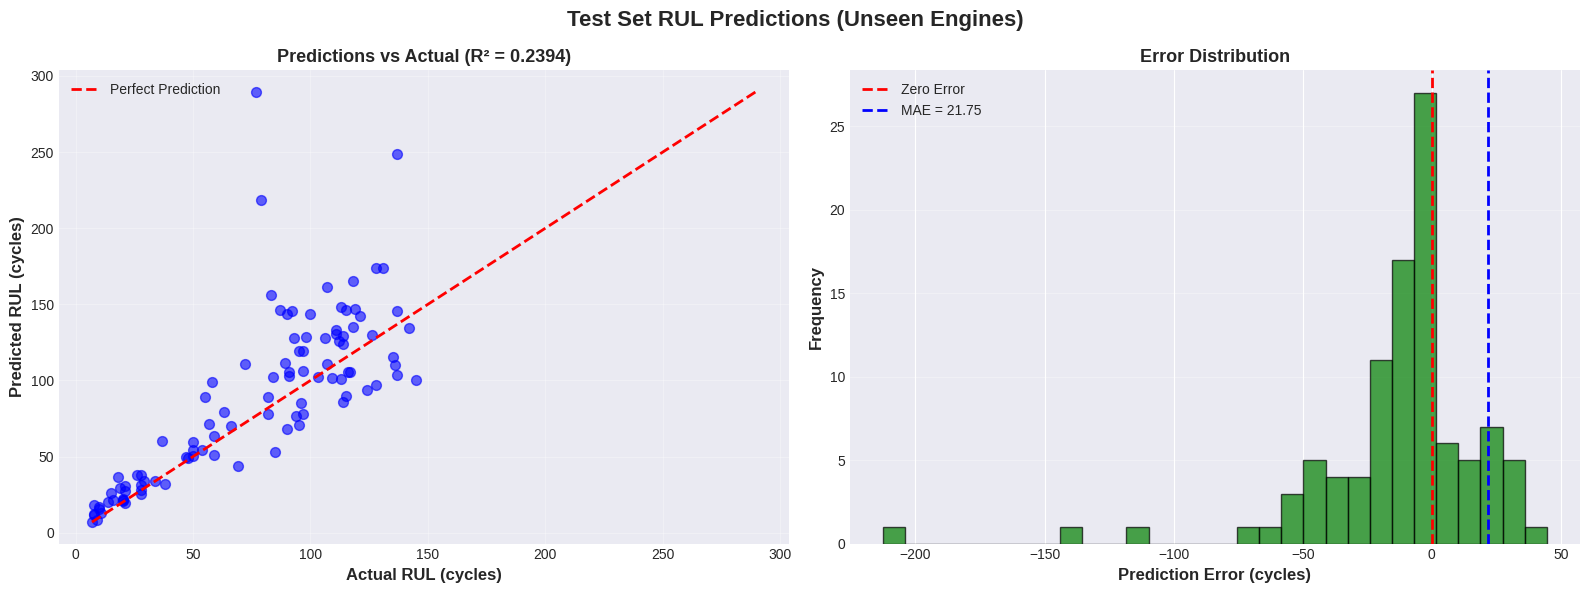

✅ Test set visualization created!


In [20]:
# Plot test set predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Test Set RUL Predictions (Unseen Engines)', fontsize=16, fontweight='bold')

# Scatter plot: Predictions vs Actual
axes[0].scatter(y_test_actual, y_test_pred, alpha=0.6, s=50, color='blue')
min_val = min(y_test_actual.min(), y_test_pred.min())
max_val = max(y_test_actual.max(), y_test_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual RUL (cycles)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted RUL (cycles)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Predictions vs Actual (R² = {r2_test:.4f})', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Error distribution
errors = y_test_actual.flatten() - y_test_pred.flatten()
axes[1].hist(errors, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(x=mae_test, color='blue', linestyle='--', linewidth=2, label=f'MAE = {mae_test:.2f}')
axes[1].set_xlabel('Prediction Error (cycles)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Error Distribution', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✅ Test set visualization created!")

## Step 14: Model Comparison Visualization

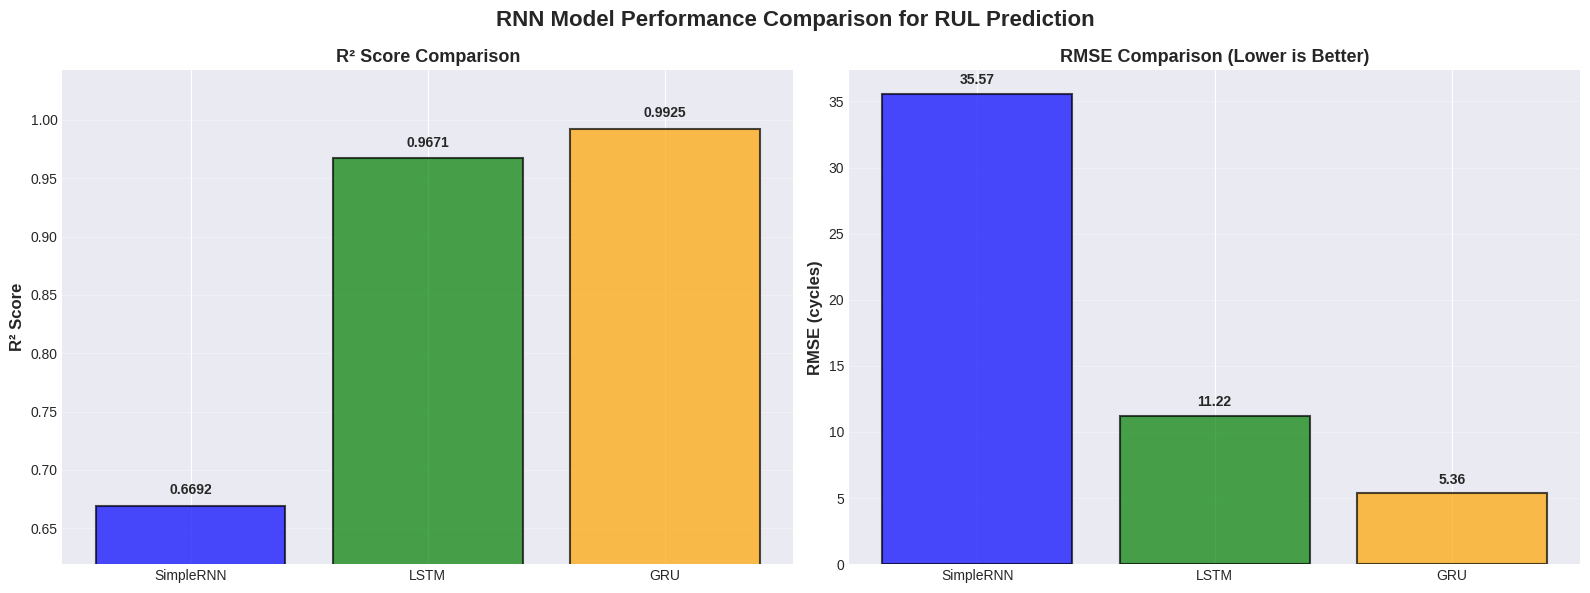

✅ Model comparison visualization created!


In [21]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RNN Model Performance Comparison for RUL Prediction', fontsize=16, fontweight='bold')

# R² comparison
models = ['SimpleRNN', 'LSTM', 'GRU']
r2_scores = [r2_simple_rnn, r2_lstm, r2_gru]
colors = ['blue', 'green', 'orange']

axes[0].bar(models, r2_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('R² Score Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylim([min(r2_scores) - 0.05, max(r2_scores) + 0.05])
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# RMSE comparison
rmse_scores = [rmse_simple_rnn, rmse_lstm, rmse_gru]

axes[1].bar(models, rmse_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('RMSE (cycles)', fontsize=12, fontweight='bold')
axes[1].set_title('RMSE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + max(rmse_scores)*0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Model comparison visualization created!")

## Step 15: Visualize Model Complexity

Let's compare the complexity of different RNN architectures for RUL prediction.

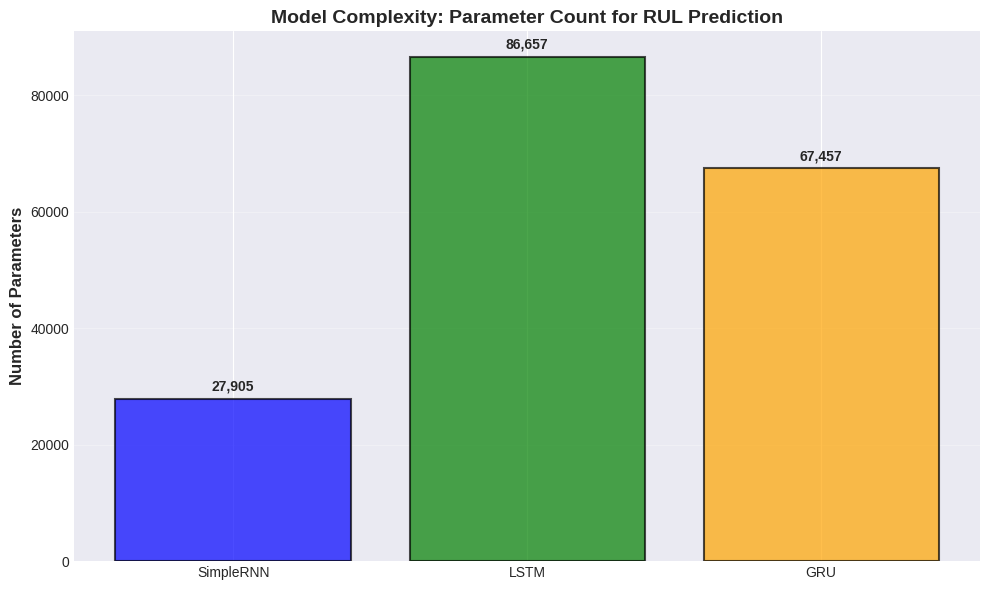

📊 Parameter Counts:
SimpleRNN    :   27,905 parameters
LSTM         :   86,657 parameters
GRU          :   67,457 parameters
\n💡 Understanding Complexity:
   - SimpleRNN: Fewest parameters, simplest
   - LSTM: Most parameters (gates add complexity)
   - GRU: Medium complexity (simpler gates than LSTM)
   - More parameters = More capacity, but needs more data


In [22]:
# Count parameters for each model
def count_parameters(model):
    return model.count_params()

param_counts = {
    'SimpleRNN': count_parameters(model_simple_rnn),
    'LSTM': count_parameters(model_lstm),
    'GRU': count_parameters(model_gru)
}

# Visualize parameter counts
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
bars = ax.bar(models, [param_counts[m] for m in models], 
             color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of Parameters', fontsize=12, fontweight='bold')
ax.set_title('Model Complexity: Parameter Count for RUL Prediction', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for i, (bar, model) in enumerate(zip(bars, models)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max(param_counts.values())*0.01,
            f'{param_counts[model]:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("📊 Parameter Counts:")
print("=" * 60)
for model in models:
    print(f"{model:12} : {param_counts[model]:>8,} parameters")

print("\\n💡 Understanding Complexity:")
print("   - SimpleRNN: Fewest parameters, simplest")
print("   - LSTM: Most parameters (gates add complexity)")
print("   - GRU: Medium complexity (simpler gates than LSTM)")
print("   - More parameters = More capacity, but needs more data")

ample 

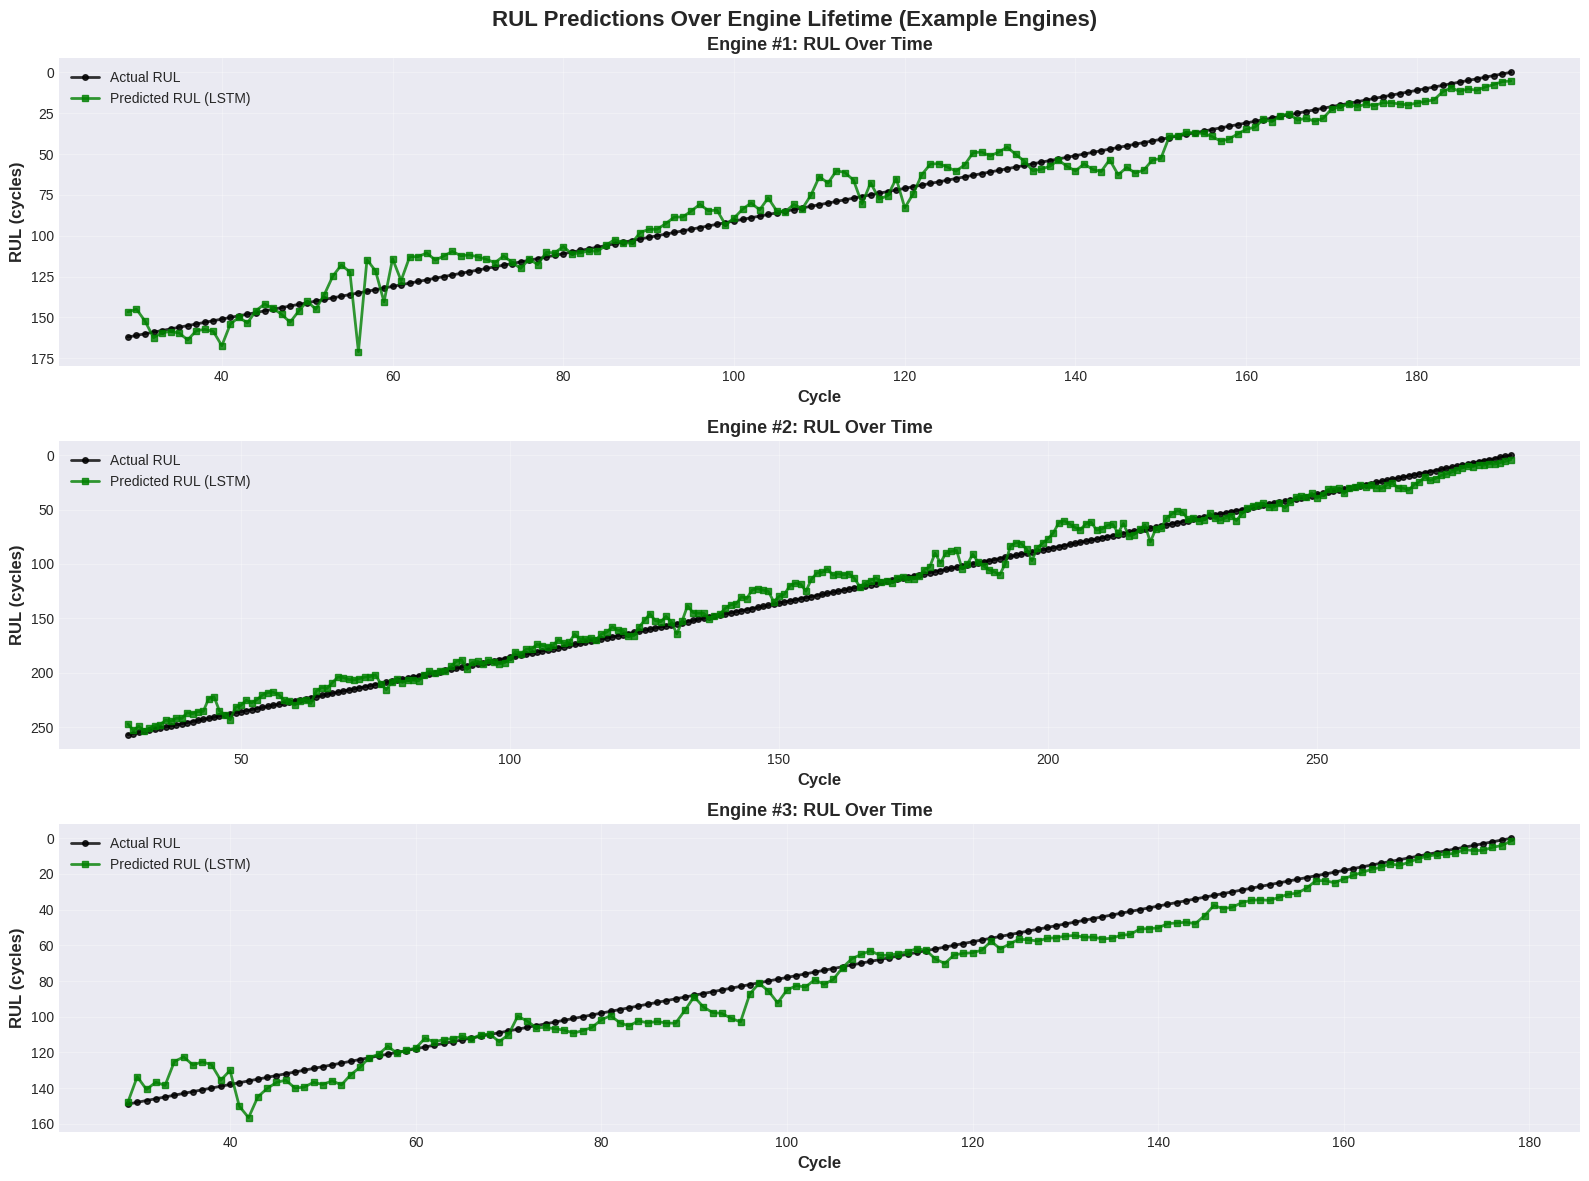

✅ RUL predictions over time visualization created!
\n💡 Observations:
   - RUL decreases as engine ages (cycles increase)
   - RNN uses sensor sequences to predict RUL
   - Predictions should follow the degradation trend


In [23]:
# Visualize RUL predictions for a few example engines from validation set
# Get sequences from same engines to track predictions
example_engines = [1, 2, 3]
fig, axes = plt.subplots(len(example_engines), 1, figsize=(16, 4*len(example_engines)))
if len(example_engines) == 1:
    axes = [axes]

fig.suptitle('RUL Predictions Over Engine Lifetime (Example Engines)', fontsize=16, fontweight='bold')

for idx, engine_id in enumerate(example_engines):
    # Get all sequences for this engine from training data
    engine_data = train_df[train_df['unit'] == engine_id].sort_values('time')
    
    # Create sequences for this engine
    engine_sequences = []
    engine_rul_actual = []
    feature_cols = op_settings + sensors
    
    for i in range(len(engine_data) - sequence_length + 1):
        seq_features = engine_data[feature_cols].iloc[i:i+sequence_length].values
        engine_sequences.append(seq_features)
        engine_rul_actual.append(engine_data['RUL'].iloc[i+sequence_length-1])
    
    if len(engine_sequences) > 0:
        # Scale and predict
        engine_seq_array = np.array(engine_sequences)
        engine_reshaped = engine_seq_array.reshape(-1, n_features)
        engine_scaled = scaler.transform(engine_reshaped)
        engine_seq_scaled = engine_scaled.reshape(engine_seq_array.shape[0], n_timesteps, n_features)
        
        # Predict with best model
        engine_rul_pred = best_model.predict(engine_seq_scaled, verbose=0)
        
        # Plot
        cycle_indices = np.arange(sequence_length-1, len(engine_data))
        axes[idx].plot(cycle_indices, engine_rul_actual, 'o-', linewidth=2, markersize=4, 
                      label='Actual RUL', color='black', alpha=0.8)
        axes[idx].plot(cycle_indices, engine_rul_pred, 's-', linewidth=2, markersize=4, 
                      label='Predicted RUL (LSTM)', color='green', alpha=0.8)
        axes[idx].set_xlabel('Cycle', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('RUL (cycles)', fontsize=12, fontweight='bold')
        axes[idx].set_title(f'Engine #{engine_id}: RUL Over Time', fontsize=13, fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
        axes[idx].invert_yaxis()  # RUL decreases over time

plt.tight_layout()
plt.show()

print("✅ RUL predictions over time visualization created!")
print("\\n💡 Observations:")
print("   - RUL decreases as engine ages (cycles increase)")
print("   - RNN uses sensor sequences to predict RUL")
print("   - Predictions should follow the degradation trend")

## 🎓 Summary and Key Takeaways

### ✅ What You've Learned:

1. **RNNs for RUL Prediction**:
   - RNNs are ideal for RUL because engine degradation is a time series problem
   - Sequences capture temporal patterns in sensor readings
   - Hidden states remember degradation history

2. **RNN Types for RUL**:
   - **SimpleRNN**: Basic, fast, good for short-term patterns
   - **LSTM**: Best for long-term degradation patterns
   - **GRU**: Balance between complexity and performance

3. **Key Concepts**:
   - **Sequences**: Sliding windows of sensor readings over time
   - **Sequence Length**: Number of cycles to use (typically 20-50)
   - **Temporal Context**: Past sensor readings inform current RUL
   - **Hidden State**: Memory of degradation patterns

4. **RNN vs Feedforward for RUL**:
   - **Feedforward**: Uses only current sensor readings (no history)
   - **RNN**: Uses sequence of sensor readings (temporal context)
   - **RNN Advantage**: Can learn degradation trends over time

### 💡 Important Insights:

- **Sequence Length Matters**: Longer sequences = more context, but harder to train
- **Temporal Patterns**: RNNs excel at learning how sensors change over time
- **Degradation Trends**: RNNs can capture gradual degradation patterns
- **Memory is Key**: Hidden states remember past degradation to predict future RUL

### 📚 When to Use RNNs vs Feedforward for RUL:

| Scenario | Best Choice | Reason |
|----------|------------|--------|
| **Single timestep** | Feedforward NN | No temporal context needed |
| **Time series patterns** | RNN/LSTM/GRU | Needs temporal context |
| **Degradation trends** | RNN/LSTM/GRU | Patterns unfold over time |
| **Long sequences** | LSTM/GRU | Better long-term memory |

### 🔧 Best Practices for RUL Prediction with RNNs:

1. **Sequence Length**: 20-50 cycles typically works well
2. **Feature Scaling**: Always scale sensor readings
3. **Architecture**: Start with LSTM or GRU (better than SimpleRNN)
4. **Early Stopping**: Monitor validation loss
5. **Sequence Creation**: Use sliding window approach
6. **Engine-wise Processing**: Create sequences per engine

### 🆚 RNN vs Feedforward for RUL:

| Aspect | Feedforward NN | RNN |
|--------|----------------|-----|
| **Input** | Current sensors only | Sequence of sensors |
| **Context** | No temporal context | Uses past cycles |
| **Pattern Learning** | Static relationships | Temporal degradation |
| **Memory** | None | Remembers degradation history |
| **Best For** | Simple patterns | Time-dependent degradation |

---

**Great job learning RNNs for RUL prediction! 🔄✈️✨**